Valgt uge: Uge 31, 2025 (2025-07-28 til 2025-08-03)

Skydække og hyggetids-sikkerhed over København, uge 31 (2025-07-28 til 2025-08-03), station Københavns Lufthavn (06180), parameter cloud_cover:
       by       date  ugedag  cloud_cover_mean_pct  ugedag_bonus_pct  hyggetid_sikkerhed_pct  observations
København 2025-07-28  Mandag             25.694444               0.0               74.305556           144
København 2025-07-29 Tirsdag             20.659722               1.0               80.340278           144
København 2025-07-30  Onsdag             56.527778               2.0               45.472222           144
København 2025-07-31 Torsdag             51.145833               3.0               51.854167           144
København 2025-08-01  Fredag             39.375000               5.0               65.625000           144
København 2025-08-02  Lørdag             63.854167               6.0               42.145833           144
København 2025-08-03  Søndag             85.937500    

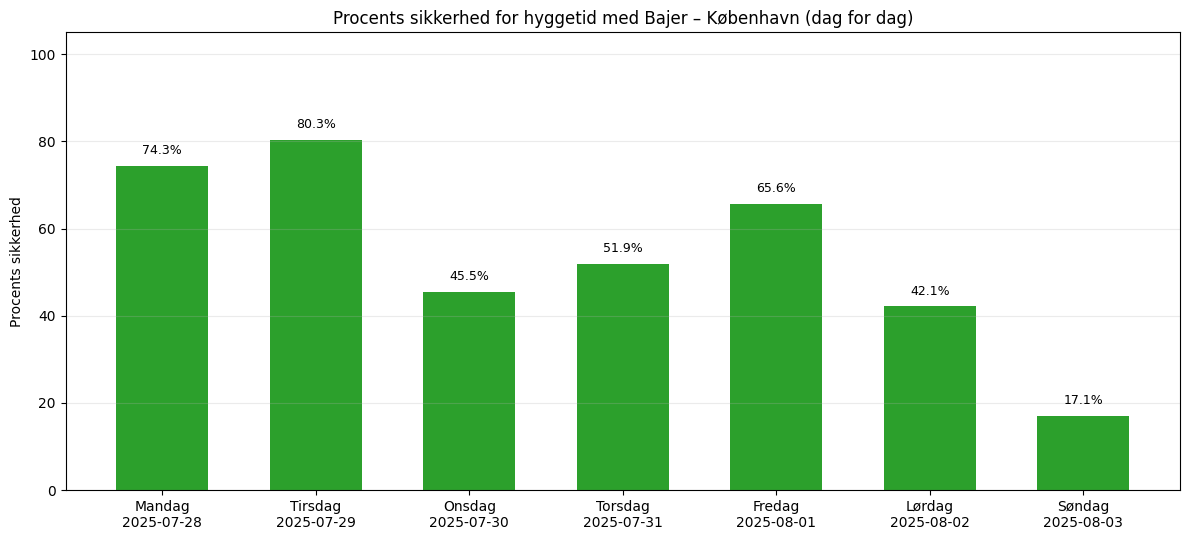

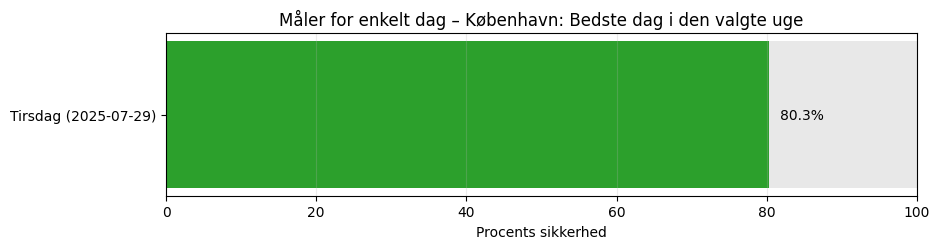


Skydække og hyggetids-sikkerhed over Århus, uge 31 (2025-07-28 til 2025-08-03), station Århus Lufthavn (06070), parameter cloud_cover:
   by       date  ugedag  cloud_cover_mean_pct  ugedag_bonus_pct  hyggetid_sikkerhed_pct  observations
Århus 2025-07-28  Mandag             46.748252               0.0               53.251748           143
Århus 2025-07-29 Tirsdag             36.631944               1.0               64.368056           144
Århus 2025-07-30  Onsdag             52.222222               2.0               49.777778           144
Århus 2025-07-31 Torsdag             40.243056               3.0               62.756944           144
Århus 2025-08-01  Fredag             47.714286               5.0               57.285714           140
Århus 2025-08-02  Lørdag             73.576389               6.0               32.423611           144
Århus 2025-08-03  Søndag             81.215278               3.0               21.784722           144


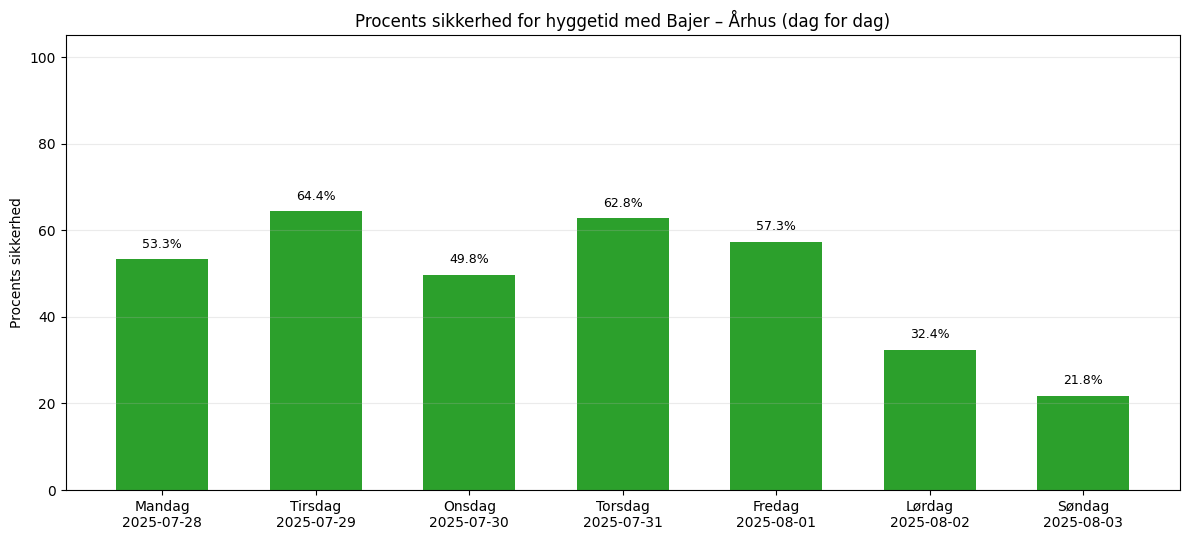

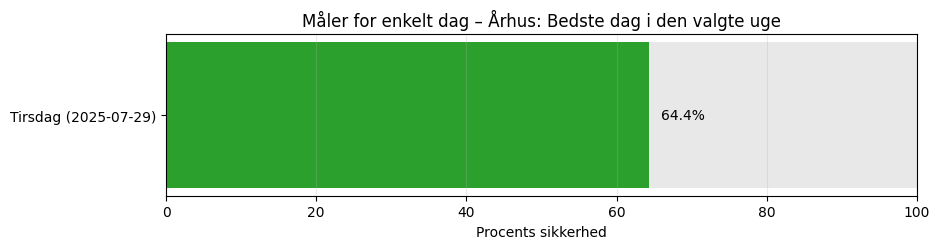


Skydække og hyggetids-sikkerhed over Odense, uge 31 (2025-07-28 til 2025-08-03), station Odense Lufthavn (06120), parameter cloud_cover:
    by       date  ugedag  cloud_cover_mean_pct  ugedag_bonus_pct  hyggetid_sikkerhed_pct  observations
Odense 2025-07-28  Mandag             24.444444               0.0               75.555556           144
Odense 2025-07-29 Tirsdag             15.416667               1.0               85.583333           144
Odense 2025-07-30  Onsdag             28.958333               2.0               73.041667           144
Odense 2025-07-31 Torsdag             55.972222               3.0               47.027778           144
Odense 2025-08-01  Fredag             55.347222               5.0               49.652778           144
Odense 2025-08-02  Lørdag             57.500000               6.0               48.500000           144
Odense 2025-08-03  Søndag             93.750000               3.0                9.250000           144


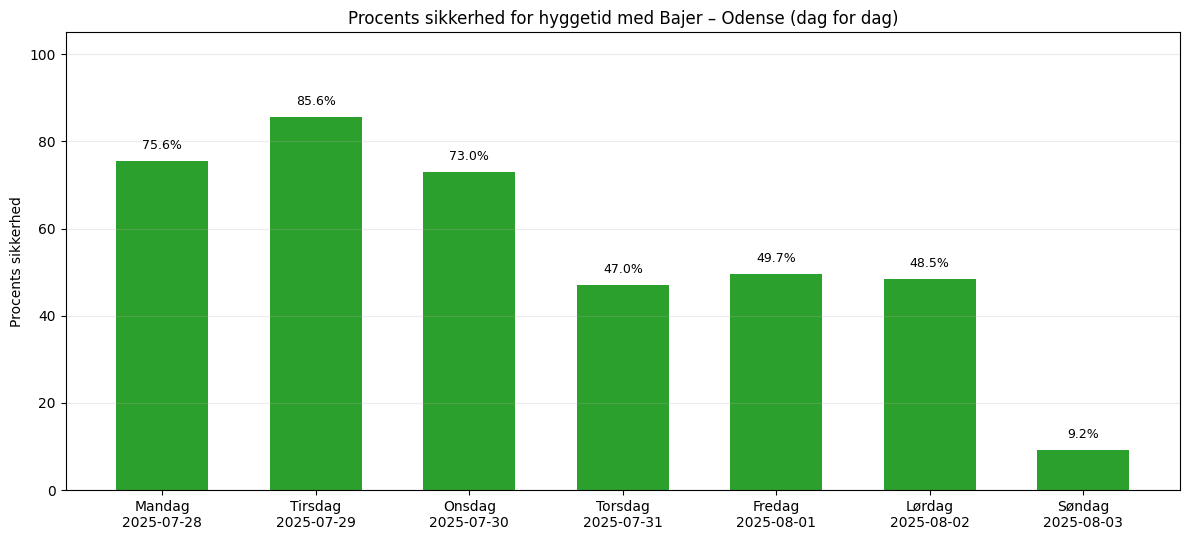

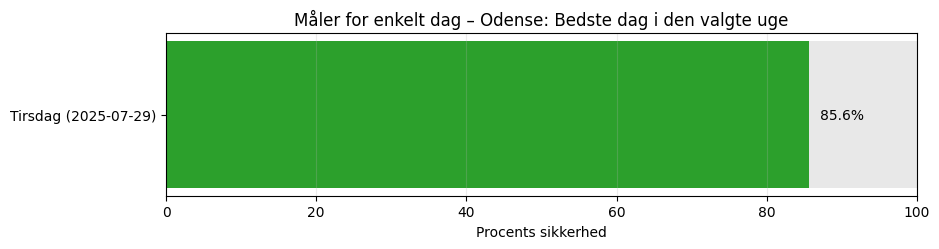

,by,date,ugedag,cloud_cover_mean_pct,ugedag_bonus_pct,hyggetid_sikkerhed_pct,observations
0,København,2025-07-28,Mandag,25.694444,0.0,74.305556,144
1,København,2025-07-29,Tirsdag,20.659722,1.0,80.340278,144
2,København,2025-07-30,Onsdag,56.527778,2.0,45.472222,144
3,København,2025-07-31,Torsdag,51.145833,3.0,51.854167,144
4,København,2025-08-01,Fredag,39.375000,5.0,65.625000,144
5,København,2025-08-02,Lørdag,63.854167,6.0,42.145833,144
6,København,2025-08-03,Søndag,85.937500,3.0,17.062500,144
7,Århus,2025-07-28,Mandag,46.748252,0.0,53.251748,143
8,Århus,2025-07-29,Tirsdag,36.631944,1.0,64.368056,144
9,Århus,2025-07-30,Onsdag,52.222222,2.0,49.777778,144


In [14]:
from datetime import datetime, timezone, timedelta
import random
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_BASE = "https://opendataapi.dmi.dk/v2/metObs"
API_KEY = ""  # Sæt evt. din nøgle her eller i miljøvariabel

def dmi_get(path: str, params: dict) -> dict:
    url = f"{API_BASE}{path}"
    q = dict(params)
    if API_KEY:
        q["api-key"] = API_KEY
    r = requests.get(url, params=q, timeout=45)
    r.raise_for_status()
    return r.json()

# 1) Vælg en tilfældig hel uge inden for det sidste år (ISO mandag->søndag)
now_utc = datetime.now(timezone.utc)
one_year_ago = now_utc - timedelta(days=365)

def pick_random_iso_week_in_last_year():
    span_seconds = (now_utc - one_year_ago).total_seconds()
    for _ in range(500):
        random_dt = one_year_ago + timedelta(seconds=random.uniform(0, span_seconds))
        iso_year, iso_week, _ = random_dt.isocalendar()
        week_start_local = datetime.fromisocalendar(iso_year, iso_week, 1).replace(tzinfo=timezone.utc)
        week_end_local = datetime.fromisocalendar(iso_year, iso_week, 7).replace(
            hour=23, minute=59, second=59, tzinfo=timezone.utc
        )
        if week_start_local >= one_year_ago and week_end_local <= now_utc:
            return iso_year, iso_week, week_start_local, week_end_local
    raise RuntimeError("Kunne ikke vælge en gyldig uge inden for det sidste år.")

YEAR, WEEK, week_start, week_end = pick_random_iso_week_in_last_year()
date_range = f"{week_start.isoformat().replace('+00:00', 'Z')}/{week_end.isoformat().replace('+00:00', 'Z')}"
print(f"Valgt uge: Uge {WEEK}, {YEAR} ({week_start.date()} til {week_end.date()})")

# 2) Hent stationsliste én gang
stations_payload = dmi_get(
    "/collections/station/items",
    {"limit": 3000},
)

# 3) Opsætning
cloud_parameter_candidates = [
    "total_cloud_cover",
    "cloud_cover",
    "cloudiness",
    "cloud_amount",
]

city_targets = [
    ("København", ["københavn", "kobenhavn", "copenhagen"]),
    ("Århus", ["århus", "aarhus", "arhus"]),
    ("Odense", ["odense"]),
]

weekday_names = {
    0: "Mandag",
    1: "Tirsdag",
    2: "Onsdag",
    3: "Torsdag",
    4: "Fredag",
    5: "Lørdag",
    6: "Søndag",
}
weekday_bonus = {
    0: 0.0,  # Mandag
    1: 1.0,  # Tirsdag
    2: 2.0,  # Onsdag
    3: 3.0,  # Torsdag
    4: 5.0,  # Fredag
    5: 6.0,  # Lørdag
    6: 3.0,  # Søndag
}

def build_daily_for_city(city_name: str, city_terms: list[str]) -> tuple[pd.DataFrame, str, str, str]:
    stations = []
    for feature in stations_payload.get("features", []):
        props = feature.get("properties", {})
        station_id = props.get("stationId")
        station_name = str(props.get("name", ""))
        name_lower = station_name.lower()
        if station_id and any(term in name_lower for term in city_terms):
            stations.append((str(station_id), station_name))

    if not stations:
        raise RuntimeError(f"Ingen station fundet for {city_name}.")

    stations.sort(key=lambda x: x[0])
    station_id, station_name = stations[0]

    parameter_id = None
    obs_payload = None
    for pid in cloud_parameter_candidates:
        try:
            payload = dmi_get(
                "/collections/observation/items",
                {
                    "stationId": station_id,
                    "parameterId": pid,
                    "datetime": date_range,
                    "limit": 300000,
                },
            )
            if payload.get("features"):
                parameter_id = pid
                obs_payload = payload
                break
        except requests.HTTPError:
            continue

    if parameter_id is None or obs_payload is None:
        raise RuntimeError(
            f"Ingen skydække-observationer for {city_name} ({station_id}) i uge {WEEK}, {YEAR}."
        )

    rows = []
    for feature in obs_payload.get("features", []):
        props = feature.get("properties", {})
        observed = props.get("observed")
        value = props.get("value")
        if observed is None or value is None:
            continue
        ts = pd.to_datetime(observed, utc=True)
        cloud_raw = float(value)
        rows.append((ts, cloud_raw))

    if not rows:
        raise RuntimeError(f"Ingen gyldige observationsrækker for {city_name}.")

    df_cloud = pd.DataFrame(rows, columns=["timestamp_utc", "cloud_raw"]).sort_values("timestamp_utc")

    raw_max = float(df_cloud["cloud_raw"].max())
    if raw_max <= 8.0:
        df_cloud["cloud_cover_pct"] = (df_cloud["cloud_raw"] / 8.0) * 100.0
    else:
        df_cloud["cloud_cover_pct"] = df_cloud["cloud_raw"].clip(lower=0.0, upper=100.0)

    df_cloud["hyggetid_basis_pct"] = (100.0 - df_cloud["cloud_cover_pct"]).clip(lower=0.0, upper=100.0)
    df_cloud["date"] = df_cloud["timestamp_utc"].dt.date

    daily_agg = (
        df_cloud.groupby("date", as_index=False)
        .agg(
            cloud_cover_mean_pct=("cloud_cover_pct", "mean"),
            hyggetid_basis_mean_pct=("hyggetid_basis_pct", "mean"),
            observations=("cloud_cover_pct", "size"),
        )
        .sort_values("date")
    )

    all_week_dates = pd.date_range(week_start.date(), week_end.date(), freq="D")
    daily = pd.DataFrame({"date": all_week_dates.date}).merge(daily_agg, on="date", how="left")
    daily["observations"] = daily["observations"].fillna(0).astype(int)

    daily["weekday_num"] = pd.to_datetime(daily["date"]).dt.weekday
    daily["ugedag"] = daily["weekday_num"].map(weekday_names)
    daily["ugedag_bonus_pct"] = daily["weekday_num"].map(weekday_bonus).astype(float)
    daily["hyggetid_sikkerhed_pct"] = (
        daily["hyggetid_basis_mean_pct"] + daily["ugedag_bonus_pct"]
    ).clip(lower=0.0, upper=100.0)

    daily["by"] = city_name
    daily = daily[[
        "by",
        "date",
        "ugedag",
        "cloud_cover_mean_pct",
        "ugedag_bonus_pct",
        "hyggetid_sikkerhed_pct",
        "observations",
    ]]

    return daily, station_id, station_name, parameter_id

all_daily = []

for city_name, city_terms in city_targets:
    try:
        daily, station_id, station_name, parameter_id = build_daily_for_city(city_name, city_terms)
    except RuntimeError as e:
        print(f"\nSpringer {city_name} over: {e}")
        continue

    print(
        f"\nSkydække og hyggetids-sikkerhed over {city_name}, uge {WEEK} "
        f"({week_start.date()} til {week_end.date()}), station {station_name} ({station_id}), parameter {parameter_id}:"
    )
    print(daily.to_string(index=False, na_rep="ingen data"))

    # Graf 1: Ugevisning for byen
    fig, ax = plt.subplots(figsize=(12, 5.5))
    x = list(range(len(daily)))
    sikkerhed_plot = daily["hyggetid_sikkerhed_pct"].fillna(0.0)

    bars = ax.bar(x, sikkerhed_plot, color="#2CA02C", width=0.6)

    labels = [f"{w}\n{d}" for w, d in zip(daily["ugedag"], daily["date"])]
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Procents sikkerhed")
    ax.set_title(f"Procents sikkerhed for hyggetid med Bajer – {city_name} (dag for dag)")
    ax.grid(axis="y", alpha=0.25)

    for i, (bar, val, obs) in enumerate(zip(bars, sikkerhed_plot, daily["observations"])):
        if obs == 0:
            ax.text(i, 3, "ingen data", ha="center", va="bottom", fontsize=8, color="#444")
        ax.text(bar.get_x() + bar.get_width() / 2, min(val + 2, 102), f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    # Graf 2: Enkelt-dagsmåler for byen
    daily_with_data = daily[daily["observations"] > 0].copy()
    if daily_with_data.empty:
        one_day_label = f"{daily.iloc[0]['ugedag']} ({daily.iloc[0]['date']})"
        one_day_value = 0.0
        one_day_note = "Ingen observationer i denne uge"
    else:
        best_idx = daily_with_data["hyggetid_sikkerhed_pct"].idxmax()
        one_day = daily.loc[best_idx]
        one_day_label = f"{one_day['ugedag']} ({one_day['date']})"
        one_day_value = float(one_day["hyggetid_sikkerhed_pct"])
        one_day_note = "Bedste dag i den valgte uge"

    fig, ax = plt.subplots(figsize=(9.5, 2.6))
    ax.barh([0], [100], color="#E8E8E8", height=0.55)
    ax.barh([0], [one_day_value], color="#2CA02C", height=0.55)
    ax.set_xlim(0, 100)
    ax.set_yticks([0])
    ax.set_yticklabels([one_day_label])
    ax.set_xlabel("Procents sikkerhed")
    ax.set_title(f"Måler for enkelt dag – {city_name}: {one_day_note}")
    ax.grid(axis="x", alpha=0.25)
    ax.text(min(one_day_value + 1.5, 98), 0, f"{one_day_value:.1f}%", va="center", ha="left", fontsize=10)

    plt.tight_layout()
    plt.show()

    all_daily.append(daily)

if not all_daily:
    raise RuntimeError("Ingen data kunne hentes for København, Århus eller Odense i den valgte uge.")

daily_all_cities = pd.concat(all_daily, ignore_index=True)
daily_all_cities